In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
cluster_data = pd.read_csv('D:\VSCODE\Project_Songs_Clustering\Music_Data_Clusters.csv')
cluster_data.head()

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,clusters
0,161427,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088,1
1,223440,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459,1
2,208267,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443,1
3,161933,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775,1
4,167973,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950,1


In [ ]:
#Checking mean values of features for each cluster
cluster_data.groupby('clusters')[['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']].mean()

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
clusters,,,,,,,,,,
0,225646.436790,0.627145,0.694955,-7.593433,0.074248,0.255972,0.050828,0.199903,0.665780,124.950103
1,214746.469988,0.488117,0.311914,-13.147142,0.058880,0.749977,0.166786,0.180935,0.416930,112.038402
2,92631.332936,0.664317,0.467724,-13.300732,0.823960,0.582988,0.001649,0.432653,0.585158,100.644361


Here, 
In cluster 0: duration_ms is high, danceability is medium, energy is high, loudness is high, speechiness is medium, acousticness is low, instrumentalness is medium, liveness is medium, valence is high, tempo is high.
In cluster 1: duration_ms is medium, danceability is low, energy is low, loudness is medium, speechiness is low, acousticness is high, instrumentalness is high, liveness is low, valence is low, tempo is medium.
In cluster 2: duration_ms is low, danceability is high, energy is medium, loudness is low, speechiness is high, acousticness is medium, instrumentalness is low, liveness is high, valence is medium, tempo is low.


So according to those values we can name each cluster as 
* Cluster 0: Party Powerhouses
* Cluster 1: Acoustic Solitude
* Cluster 2: Lyrical Grooves

In [4]:
cluster_mapping = {
    0:'Party Powerhouses',
    1:'Acoustic Solitude',
    2:'Lyrical Grooves'
}

cluster_data['clusters'] = cluster_data['clusters'].map(cluster_mapping)

In [5]:
cluster_data.head()

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,clusters
0,161427,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088,Acoustic Solitude
1,223440,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459,Acoustic Solitude
2,208267,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443,Acoustic Solitude
3,161933,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775,Acoustic Solitude
4,167973,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950,Acoustic Solitude


Visualization

In [6]:
X=cluster_data.drop('clusters', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#Reducing the dataset to 2 components to visualize clusters
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(X_scaled)
pca_data.shape

(95495, 2)

In [8]:
PCA_df = pd.DataFrame(pca_data, columns=['PCA1', 'PCA2'])
PCA_df.head()

,PCA1,PCA2
0,-1.740225,0.162850
1,-2.548878,-0.857319
2,-2.535048,0.096515
3,-0.785979,0.679295
4,-1.618619,1.227818


In [9]:
y = cluster_data['clusters']

In [ ]:
PCA_df_final = pd.concat([PCA_df, y], axis=1)
PCA_df_final.head()

,PCA1,PCA2,clusters
0,-1.740225,0.162850,Acoustic Solitude
1,-2.548878,-0.857319,Acoustic Solitude
2,-2.535048,0.096515,Acoustic Solitude
3,-0.785979,0.679295,Acoustic Solitude
4,-1.618619,1.227818,Acoustic Solitude


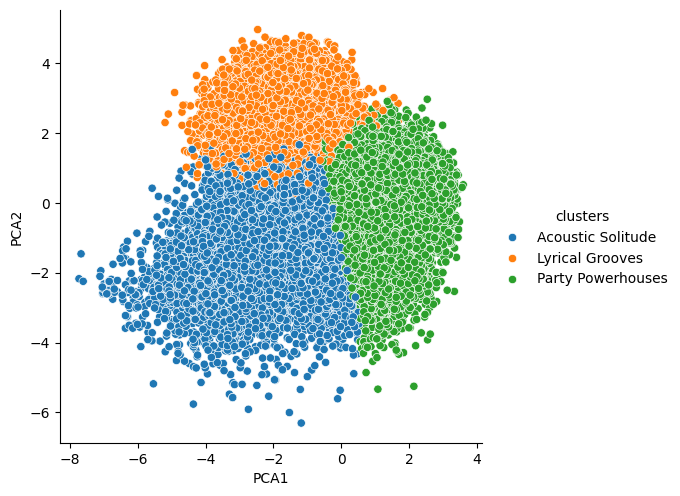

In [ ]:
sns.pairplot(data=PCA_df_final, x_vars=['PCA1'], y_vars=['PCA2'], hue='clusters', height=5)
plt.show()

In [10]:
X_Scaled_df = pd.DataFrame(X_scaled, columns=['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'])
X_Scaled_df = pd.concat([X_Scaled_df, y], axis=1)
X_Scaled_df.head()


,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,clusters
0,-0.519210,-0.156034,-1.514098,-0.768344,-0.425622,1.619264,-0.352372,0.543008,0.318872,0.513720,Acoustic Solitude
1,0.226386,-1.032273,-1.531037,-1.111646,-0.368071,1.607151,-0.352439,-0.520829,-0.580436,-1.296587,Acoustic Solitude
2,0.043958,-0.491067,-1.420930,-1.141139,-0.396482,1.625321,-0.352439,1.045226,-0.378798,-1.562223,Acoustic Solitude
3,-0.513126,0.572017,-0.315623,-0.478934,-0.011104,1.613208,-0.352439,-0.029412,0.609232,0.403933,Acoustic Solitude
4,-0.440506,0.404501,-1.031320,-0.778740,-0.109452,1.613208,-0.352439,0.802217,1.085099,-1.379731,Acoustic Solitude


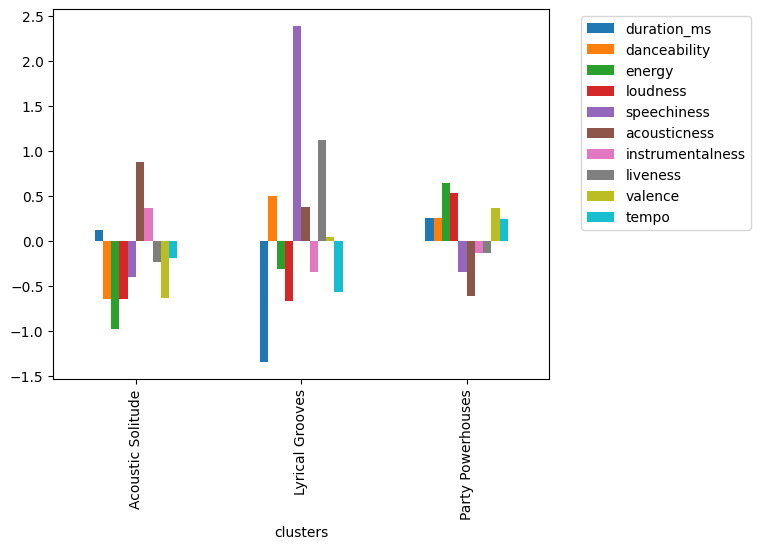

In [13]:
X_Scaled_df.groupby('clusters')[['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']].mean().plot.bar()
plt.legend(bbox_to_anchor = (1.05, 1), loc='upper left')
plt.show()

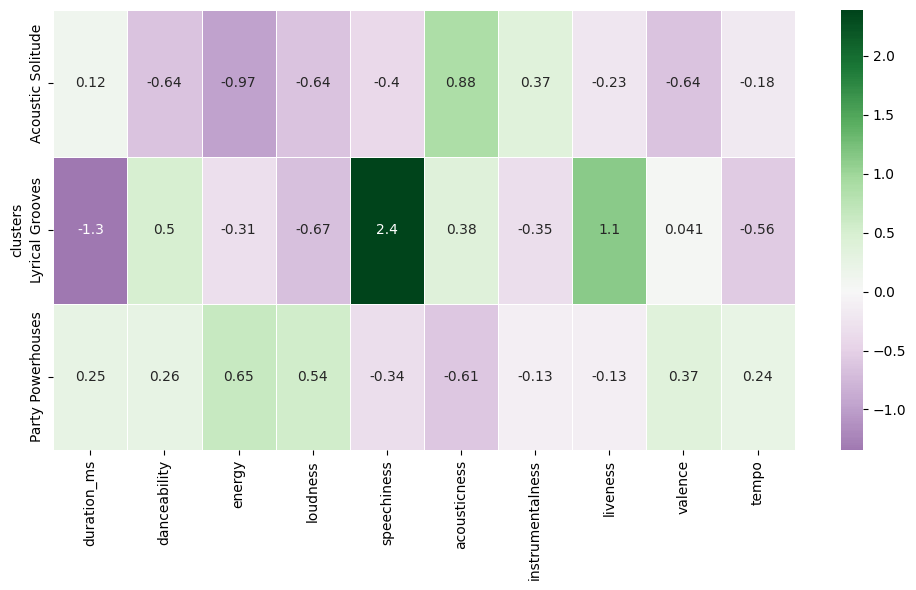

In [22]:
clustered_scale_means = X_Scaled_df.groupby('clusters').mean()
plt.figure(figsize=(10, 6))
sns.heatmap(clustered_scale_means, annot=True, cmap='PRGn', center=0, linewidths=0.5)
plt.tight_layout()
plt.show()

In [33]:
final_data = pd.read_csv('C:/Users/HP/OneDrive/Desktop/GUVI-DS PROJECT REPORTS/single_genre_artists.csv')
final_data.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [24]:
cluster_data.head()

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,clusters
0,161427,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088,Acoustic Solitude
1,223440,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459,Acoustic Solitude
2,208267,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443,Acoustic Solitude
3,161933,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775,Acoustic Solitude
4,167973,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950,Acoustic Solitude


In [29]:
cluster_data.shape

(95495, 11)

In [ ]:
#Adding cluster labels to original DataFrame
final_data_clusters = pd.merge(final_data, cluster_data['clusters'], left_index=True, right_index=True, how='inner')

In [43]:
final_data_clusters.shape

(95495, 24)

In [44]:
final_data_clusters.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists,clusters
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22,Acoustic Solitude
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22,Acoustic Solitude
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22,Acoustic Solitude
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22,Acoustic Solitude
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22,Acoustic Solitude


In [45]:
final_data_clusters = final_data_clusters.rename(columns={'clusters':'song_genre'})

In [ ]:
#Exporting the final dataset to csv
final_data_clusters.to_csv('D:\VSCODE\Project_Songs_Clustering\Final_Music_Data_Clusters.csv', index=False)